In [1]:
!pip install torch transformers umap-learn

In [14]:
# Imports
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import random, os, json
from itertools import product
from collections import defaultdict

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data

import numpy as np
import umap
import matplotlib.pyplot as plt

MODE = "full" # "full" for full implementation of antropic strategy, "standard" for standard baseline
MODEL_NAME = "./codebert-base-mlm"

In [15]:
# Load dataset

f = open("./data/packet_inspection/packets_dataset.jsonl", "r")
ai_dataset = [json.loads(line) for line in f.readlines()]
f.close()

In [16]:
# Getting Data activations


model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, output_hidden_states=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
layer = 10

inputs = [s["text"] for s in ai_dataset]
tokens_id = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
activations =  model(**tokens_id).hidden_states

num_samples, num_tokens, _ = activations[layer].shape
tokens = [{"tokens_str": ["CLS"] + tokenizer.tokenize(s["text"], truncation=True,padding="max_length", max_length=num_tokens) + ["</s>"], "class": s["class"]} for s in ai_dataset]

print("Done gathering inputs")

Done gathering inputs


In [17]:
class SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

In [ ]:
# Utility functions for SAE analysis
def calculate_sae_loss(x, W_enc, b_enc, W_dec, b_dec, lambd):
    """
    Calcola la loss function per uno Sparse AutoEncoder come specificato nell'immagine.

    Args:
        x (torch.Tensor): Tensore dei dati di input, di forma (batch_size, D).
        W_enc (torch.Tensor): Pesi dell'encoder, di forma (F, D).
        b_enc (torch.Tensor): Bias dell'encoder, di forma (F,).
        W_dec (torch.Tensor): Pesi del decoder, di forma (D, F).
        b_dec (torch.Tensor): Bias del decoder, di forma (D,).
        lambd (float): Parametro di regolarizzazione.

    Returns:
        torch.Tensor: Il valore scalare della loss.
    """
    
    # Formula: f(x) = ReLU(W_enc * x + b_enc)
    f_x = torch.relu(torch.matmul(x, W_enc.T) + b_enc)
    
    # Formula: x_hat = W_dec * f(x) + b_dec
    x_hat = torch.matmul(f_x, W_dec.T) + b_dec
    
    # --- 1. Reconstruction Loss ---
    reconstruction_loss = torch.mean(torch.sum((x - x_hat)**2, dim=1))

    # --- 2. Termine di Sparsità/Regolarizzazione ---
    # Formula: lambda * E_x [ sum_i f_i(x) * ||W_dec[:,i]||_2 ]

    # a. Calcola la norma L2 (Euclidea) di ciascuna colonna di W_dec (corrispondente a W_dec[:,i])
    # torch.linalg.norm(W_dec, dim=0, ord=2) calcola ||W_dec[:,i]||_2 per tutte le i.
    # Risultato: un tensore di dimensione [F]
    decoder_l2_norms = torch.linalg.norm(W_dec, dim=0, ord=2)

    # b. Calcola f_i(x) * ||W_dec[:,i]||_2
    # encoded (Batch_size x F) viene moltiplicato per decoder_l2_norms (F).
    # Il broadcasting assicura che ogni f_i(x) sia moltiplicato per il suo rispettivo ||W_dec[:,i]||_2.
    weighted_activations = f_x * decoder_l2_norms

    # c. Calcola la somma su tutte le feature (sum_i) e il Valore Atteso (E_x tramite mean sul batch)
    # Somma su tutte le feature (dim=1)
    sum_of_weighted_activations = torch.sum(weighted_activations, dim=1)
    
    # Calcola il valore atteso sul batch (media)
    mean_regularization_term = torch.mean(sum_of_weighted_activations)

    # Calcola il termine di regolarizzazione
    regularization_loss = lambd * mean_regularization_term

    # --- 3. Perdita Totale ---
    total_loss = reconstruction_loss + regularization_loss
    
    return total_loss


def get_feature_directions(W_dec):
    """
    Calcola i vettori di direzione delle feature a partire dalla matrice dei pesi del decoder.

    Args:
        W_dec (torch.Tensor): Pesi del decoder di forma (D, F), dove
                              D è la dimensione residua e F la dimensione delle feature.

    Returns:
        torch.Tensor: I vettori delle feature (direzioni normalizzate), di forma (D, F).
    """
    # Calcola la norma L2 di ogni colonna (dim=0) della matrice W_dec.
    # Aggiunge 1e-8 per evitare divisioni per zero.
    norms = torch.linalg.norm(W_dec, dim=0)
    
    # Normalizza ogni colonna (vettore di feature) dividendo per la sua norma.
    feature_directions = W_dec / (norms + 1e-8)
    
    return feature_directions

def get_feature_activations(x, W_enc, b_enc, W_dec):
    """
    Calcola le attivazioni delle feature per un dato input x.

    Args:
        x (torch.Tensor): Tensore dei dati di input, di forma (batch_size, D).
        W_enc (torch.Tensor): Pesi dell'encoder, di forma (F, D).
        b_enc (torch.Tensor): Bias dell'encoder, di forma (F,).
        W_dec (torch.Tensor): Pesi del decoder, di forma (D, F).

    Returns:
        torch.Tensor: Le attivazioni delle feature, di forma (batch_size, F).
    """
    # Calcolo delle attivazioni dei feature (f_i(x) = ReLU(W_enc * x + b_enc))
    f_x = torch.relu(torch.matmul(x, W_enc.T) + b_enc)
    
    norm_W_dec = torch.linalg.norm(W_dec, dim=0)
    
    feature_activations = f_x * norm_W_dec
    
    return feature_activations

[Dim 768] Sparsità media (numero di feature attive per singolo token): 107.3426
[Dim 768] Valore medio feature attive: 0.4440
[Dim 768] Numero di dead features (mai attivate): 134 su 768
[Dim 768] Top 10 feature (concetti) più attive:
98 0.8767115473747253
Feature 98: attivazione media = 0.8767
502 0.7813625931739807
Feature 502: attivazione media = 0.7814
650 0.3462706506252289
Feature 650: attivazione media = 0.3463
222 0.31374412775039673
Feature 222: attivazione media = 0.3137
355 0.2893312871456146
Feature 355: attivazione media = 0.2893
49 0.2836332619190216
Feature 49: attivazione media = 0.2836
762 0.24921414256095886
Feature 762: attivazione media = 0.2492
163 0.2386527806520462
Feature 163: attivazione media = 0.2387
298 0.2187981754541397
Feature 298: attivazione media = 0.2188
8 0.20395010709762573
Feature 8: attivazione media = 0.2040
[Dim 1536] Sparsità media (numero di feature attive per singolo token): 212.1715
[Dim 1536] Valore medio feature attive: 0.3171
[Dim 1536] N

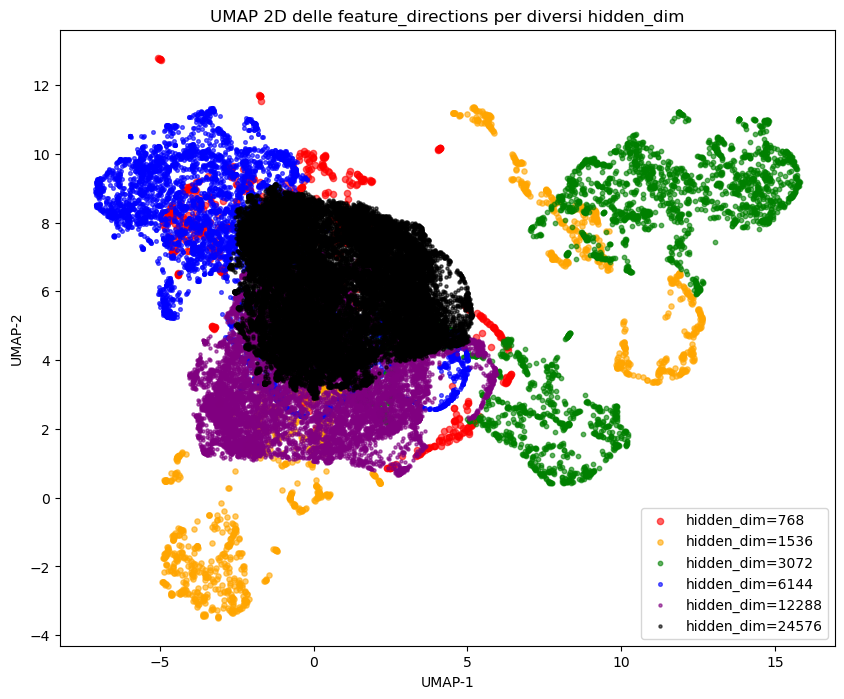

In [ ]:
# Analyzing feature statistics for all saes

hidden_dims = [768, 768*2, 768*4, 768*8, 768*16, 768*32] 
layer = 10
beta = 5.0
lr = 5e-5
input_dim = 768

threshold = 0.01
feature_directions_dict = {}
feature_activations_dict = {}

feature_to_visualize = {}


for hidden_dim in hidden_dims:
    
    feature_to_visualize[hidden_dim] = []
    
    sae = SAE(input_dim, hidden_dim)
    sae.load_state_dict(torch.load(f"saved_models/sae_layer_{layer}_hiddim_{hidden_dim}_{MODE}.pt"))
    encoder_weights = sae.encoder[0].weight
    decoder_weights = sae.decoder[0].weight
    feature_directions = get_feature_directions(decoder_weights)
    feature_activations = get_feature_activations(activations[layer], encoder_weights, sae.encoder[0].bias, decoder_weights)
    feature_directions_dict[hidden_dim] = feature_directions
    feature_activations_dict[hidden_dim] = feature_activations

        
    nonzero_counts = (feature_activations >= threshold).sum(dim=2)  # shape: (100, 512)
    flattened_nonzero_counts = nonzero_counts.flatten()
    sparsity = flattened_nonzero_counts.float().mean().item()
    print(f"[Dim {hidden_dim}] Sparsità media (numero di feature con valore > {threshold} medio per token): {sparsity:.4f}")

    mean_activations = feature_activations.mean(dim=(0,1)) # shape: (hidden_dim)
    live_features = (mean_activations > threshold).float().mean().item()
    print(f"[Dim {hidden_dim}] Percentuale feature con attivazione media > {threshold}: {live_features*100:.4f}%")

    # Calcola per ogni feature (sull'ultima dimensione) se è sempre zero su tutti i token di tutti i sample

    dead_features = (feature_activations < threshold).all(dim=(0, 1)).sum().item()
    print(f"[Dim {hidden_dim}] Numero di dead features (con attivazione sempre < {threshold}): {dead_features} su {len(mean_activations)}")

    top_features = torch.topk(mean_activations, k=10)
    feature_to_visualize[hidden_dim].append({"top_indices": top_features.indices.tolist()})
    
    print(f"[Dim {hidden_dim}] Top 10 feature (concetti) più attive:")
    for idx, value in zip(top_features.indices.tolist(), top_features.values.tolist()):
        print(idx, value)
        print(f"Feature {idx}: attivazione media = {value:.4f}")
        

import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, n_neighbors=15, metric="cosine")
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
plt.figure(figsize=(10, 8))

min_hd = min(hidden_dims)
base_size = 20
# scala la dimensione dei punti in modo decrescente al crescere di hidden_dim
sizes = [max(5, base_size * (min_hd / hd) ** 0.5) for hd in hidden_dims]

for i, hidden_dim in enumerate(hidden_dims):
    fd = feature_directions_dict[hidden_dim].detach().cpu().numpy().T  # shape: (hidden_dim, input_dim)
    embedding = reducer.fit_transform(fd)
    plt.scatter(
        embedding[:, 0], embedding[:, 1],
        label=f"hidden_dim={hidden_dim}",
        alpha=0.6, s=sizes[i], color=colors[i % len(colors)]
    )

plt.title("UMAP 2D delle feature_directions per diversi hidden_dim")
plt.legend()
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [20]:
class_common = {}   # intersezione (feature attive in TUTTI i sample della classe)
class_any = {}      # unione (feature attive in ALMENO un sample della classe)

# Analysis of each sample in each sae

for hidden_dim in hidden_dims:
    sae = SAE(input_dim, hidden_dim)
    sae.load_state_dict(torch.load(f"saved_models/sae_layer_{layer}_hiddim_{hidden_dim}_{MODE}.pt"))
    encoder_weights = sae.encoder[0].weight
    decoder_weights = sae.decoder[0].weight
    feature_directions = feature_directions_dict[hidden_dim]
    feature_activations = feature_activations_dict[hidden_dim]
    
    class_common[hidden_dim] = {}
    class_any[hidden_dim] = {}

    
    output = []
    num_samples, num_tokens, hidden_dim = feature_activations.shape
            
    for sample_idx in tqdm(range(num_samples)):

        cls = tokens[sample_idx]["class"]

        # attivazioni del sample: shape (num_tokens, hidden_dim)
        sample_acts = feature_activations[sample_idx]

        # feature attive su tutti i token del sample / su almeno un token del sample
        active_features = set()
        mask = (sample_acts > threshold).any(dim=0)  # (hidden_dim,) boolean tensor
        active_idx = torch.nonzero(mask, as_tuple=False).squeeze(-1)
        active_features = set(active_idx.tolist()) if active_idx.numel() > 0 else set()
        
        if class_common[hidden_dim].get(cls) is None:
            class_common[hidden_dim][cls] = set(active_features)
        else:
            class_common[hidden_dim][cls] = class_common[hidden_dim][cls].intersection(active_features)
            
        if class_any[hidden_dim].get(cls) is None:
            class_any[hidden_dim][cls] = set(active_features)
        else:
            class_any[hidden_dim][cls] = class_any[hidden_dim][cls].union(active_features)

100%|██████████| 258/258 [00:03<00:00, 86.00it/s]


In [ ]:
# Print analysis results

for hidden_dim in hidden_dims:

	print(f"\n=== hidden_dim = {hidden_dim} ===")

	any_dict = class_any[hidden_dim]
	common_dict = class_common[hidden_dim]

	# precompute union per hidden_dim for unique calculation
	all_classes = list(any_dict.keys())
	for cls in sorted(all_classes):
		any_set = any_dict.get(cls, set())
		common_set = common_dict.get(cls, set())

		# unique to this class (in its union but in no other class union)
		other_union = set().union(*(any_dict[c] for c in all_classes if c != cls))
		unique_set = common_set - other_union

		# Store the feature sets for visualization
		feature_to_visualize[hidden_dim].append({
			'class': cls,
			# 'common': common_set,
			# 'any': any_set,
			'unique': unique_set
		})

		# compute how many features are active in exactly one sample of this class
		# uses feature_activations_dict[hidden_dim] (shape: num_samples x num_tokens x hidden_dim)
		fa = feature_activations_dict[hidden_dim]  # tensor

		# find sample indices belonging to this class
		sample_idxs = [i for i, t in enumerate(tokens) if t["class"] == cls]
		if len(sample_idxs) == 0:
			activated_once_count = 0
		else:
			# slice and compute per-sample whether each feature is active (any token)
			class_acts = fa[sample_idxs]  # (n_samples_cls, n_tokens, hidden_dim)
			per_sample_active = (class_acts != 0).any(dim=1).float()  # (n_samples_cls, hidden_dim)
			active_counts_per_feature = per_sample_active.sum(dim=0)  # (hidden_dim,)
			activated_once_count = int((active_counts_per_feature == 1).sum().item())

		print(f"\nClasse = {cls}")
		print(f"  - Feature sempre attive (intersection across samples): {len(common_set)}")
		print(f"    Example indices (up to 20): {sorted(list(common_set))[:20]}")
		print(f"  - Feature attivate almeno una volta (union across samples): {len(any_set)}")
		print(f"    Example indices (up to 20): {sorted(list(any_set))[:20]}")
		print(f"  - Feature uniche alla classe (presenti solo in questa classe): {len(unique_set)}")
		print(f"    Example indices (up to 20): {sorted(list(unique_set))[:20]}")
		print(f"  - Feature attivate esattamente in una singola sample della classe: {activated_once_count}")



=== hidden_dim = 768 ===

Classe = Adware
  - Feature sempre attive (intersection across samples): 323
    Example indices (up to 20): [3, 6, 7, 8, 9, 14, 18, 19, 20, 22, 24, 26, 27, 29, 32, 36, 37, 38, 39, 40]
  - Feature attivate almeno una volta (union across samples): 622
    Example indices (up to 20): [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  - Feature uniche alla classe (presenti solo in questa classe): 0
    Example indices (up to 20): []
  - Feature attivate esattamente in una singola sample della classe: 36

Classe = Backdoor
  - Feature sempre attive (intersection across samples): 504
    Example indices (up to 20): [3, 5, 6, 7, 8, 9, 10, 14, 15, 18, 19, 22, 23, 24, 26, 27, 29, 32, 34, 35]
  - Feature attivate almeno una volta (union across samples): 608
    Example indices (up to 20): [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  - Feature uniche alla classe (presenti solo in questa classe): 0
    Example indice

In [22]:
from collections import Counter

# Per ogni hidden_dim, verifica se due o più classi condividono feature (sia nella intersezione "common"
# — feature attive in TUTTI i sample della classe — sia nella unione "any" — feature attive in almeno un sample).

class_common_new = {}
class_any_new = {}

for hidden_dim in hidden_dims:
    print(f"\n=== hidden_dim = {hidden_dim} ===")
    # Trova le feature presenti in tutte le classi (intersezione su class_any) e rimuovile dalle statistiche successive
    any_dict_hd = class_any.get(hidden_dim, {})
    classes_hd = sorted(any_dict_hd.keys())

    if not classes_hd:
        global_common = set()
    else:
        # intersezione iterativa delle union per ogni classe
        iter_cls = iter(classes_hd)
        global_common = set(any_dict_hd[next(iter_cls)])  # copia del primo set
        for c in iter_cls:
            global_common &= any_dict_hd.get(c, set())

    print(f"Feature comuni a TUTTE le classi (presenti in almeno un sample di ogni classe): {len(global_common)}")
    print(f"  Esempi (fino a 50): {sorted(global_common)[:50]}")

    # Rimuovi queste feature dalle strutture usate dalle statistiche successive
    class_any_new[hidden_dim] = {}
    class_common_new[hidden_dim] = {}
    
    for c in classes_hd:
        if c in class_any[hidden_dim]:
            class_any_new[hidden_dim][c] = class_any[hidden_dim][c] - global_common
        if c in class_common[hidden_dim]:
            class_common_new[hidden_dim][c] = class_common[hidden_dim][c] - global_common
    
    # Set up new class dicts for stats
    any_dict = class_any_new[hidden_dim]
    common_dict = class_common_new[hidden_dim]
    classes = sorted(any_dict.keys())

    # 1) coppie di classi con intersezioni non vuote (sulle common)
    found_common_pair = False
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            c1, c2 = classes[i], classes[j]
            set1 = common_dict.get(c1, set())
            set2 = common_dict.get(c2, set())
            inter = set1 & set2
            if inter:
                found_common_pair = True
                feature_to_visualize[hidden_dim].append({
					'class_pair': (c1, c2),
					'common': inter
				})
                print(f"Classi '{c1}' & '{c2}' - feature comuni in COMMON (attive in tutti i sample di entrambe): {len(inter)}")
                print(f"  Esempi (fino a 50): {sorted(list(inter))[:50]}")

    if not found_common_pair:
        print("Nessuna coppia di classi con feature in comune nella 'common' (feature attive in TUTTI i sample).")


    # 2) feature che appaiono in >=2 classi (globalmente), sia per 'common' che per 'any'
    counter_common = Counter()
    counter_any = Counter()
    for cls in classes:
        for f in common_dict.get(cls, set()):
            counter_common[f] += 1
        for f in any_dict.get(cls, set()):
            counter_any[f] += 1

    multi_common = [f for f, cnt in counter_common.items() if cnt >= 2]
    multi_any = [f for f, cnt in counter_any.items() if cnt >= 2]
    
    feature_to_visualize[hidden_dim].append({
		'multi_common': multi_common,
		# 'multi_any': multi_any
	})

    print(f"Feature presenti in >=2 classi (COMMON): {len(multi_common)}; esempi (fino a 50): {sorted(multi_common)[:50]}")
    print(f"Feature presenti in >=2 classi (ANY):    {len(multi_any)}; esempi (fino a 50): {sorted(multi_any)[:50]}")


=== hidden_dim = 768 ===
Feature comuni a TUTTE le classi (presenti in almeno un sample di ogni classe): 591
  Esempi (fino a 50): [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 46, 47, 48, 49, 50, 51, 55, 56, 57, 59, 62]
Classi 'Botnet' & 'Spyware' - feature comuni in COMMON (attive in tutti i sample di entrambe): 1
  Esempi (fino a 50): [636]
Classi 'Botnet' & 'Trojan' - feature comuni in COMMON (attive in tutti i sample di entrambe): 1
  Esempi (fino a 50): [401]
Classi 'Botnet' & 'XSS' - feature comuni in COMMON (attive in tutti i sample di entrambe): 1
  Esempi (fino a 50): [546]
Feature presenti in >=2 classi (COMMON): 3; esempi (fino a 50): [401, 546, 636]
Feature presenti in >=2 classi (ANY):    35; esempi (fino a 50): [44, 67, 106, 116, 173, 209, 227, 276, 322, 336, 354, 379, 381, 401, 405, 472, 498, 519, 520, 522, 546, 595, 598, 609, 610, 635, 636, 647, 682, 691, 704, 714, 7

In [ ]:
SKIP = False

if SKIP == False:
	os.makedirs("outputs", exist_ok=True)
	
	for hidden_dim in hidden_dims:
		# costruisci l'insieme delle feature da considerare per questo hidden_dim
		allowed_features = set()
		for item in feature_to_visualize.get(hidden_dim, []):
			if isinstance(item, dict):
				for k, v in item.items():
					# salta chiavi non rilevanti che contengono nomi di classi o coppie di classi
					if k in ("class", "class_pair"):
						continue
					if v is None:
						continue
					if isinstance(v, (set, list, tuple)):
						allowed_features.update(int(x) for x in v)
					elif isinstance(v, int):
						allowed_features.add(int(v))
			elif isinstance(item, (set, list, tuple)):
				allowed_features.update(int(x) for x in item)
			elif isinstance(item, int):
				allowed_features.add(int(item))
		print(len(allowed_features))
		fa = feature_activations_dict[hidden_dim]  # tensor shape: (num_samples, num_tokens, hidden_dim)
		num_samples, num_tokens, _ = fa.shape
		out_path = f"outputs/sae_layer_{layer}_hiddim_{hidden_dim}_{MODE}_tokens.json"
		with open(out_path, "w", encoding="utf-8") as fout:
			samples = []
			for sample_idx in tqdm(range(num_samples), desc=f"export hiddim={hidden_dim}"):
				sample_tokens_str = tokens[sample_idx]["tokens_str"]
				cls = tokens[sample_idx]["class"]

				tokens_json = []
				for tok_idx in range(num_tokens):
					token_str = sample_tokens_str[tok_idx] if tok_idx < len(sample_tokens_str) else ""
					if token_str == "<pad>":
						nonzero = feature_activations[sample_idx, tok_idx].nonzero().squeeze().tolist()
						if isinstance(nonzero, int):
							nonzero = [nonzero]
						activations_ = [
							(int(i), float(feature_activations[sample_idx, tok_idx, i].item()))
							for i in nonzero
							if feature_activations[sample_idx, tok_idx, i] != 0
						]
						tokens_json.append({
							"token_idx": tok_idx,
							"token_str": "</s>",
							"activations": activations_
						})
						break  # Stop at first <pad>
					else:
						vec = fa[sample_idx, tok_idx].cpu()
						nonzero_idx = torch.nonzero(vec != 0, as_tuple=False).squeeze(-1)
						activations_ = []
						if nonzero_idx.numel() > 0:
							# filtra solo le feature presenti in allowed_features
							for fid in nonzero_idx.tolist():
								if fid in allowed_features:
									activations_.append((int(fid), float(vec[fid].item())))

						tokens_json.append({
							"token_idx": tok_idx,
							"token_str": token_str,
							"activations": activations_
						})

				sample_json = {
					"sample_index": sample_idx,
					"tokens": tokens_json,
					"class": cls
				}
				samples.append(sample_json)
			fout.write(json.dumps(samples))
		print(f"Wrote {out_path}")

else:
	print("skipped")

3


export hiddim=768: 100%|██████████| 258/258 [00:21<00:00, 12.28it/s]


Wrote outputs/sae_layer_10_hiddim_768_full_tokens.json
4


export hiddim=1536: 100%|██████████| 258/258 [00:23<00:00, 10.79it/s]


Wrote outputs/sae_layer_10_hiddim_1536_full_tokens.json
7


...

Wrote outputs/sae_layer_10_hiddim_6144_full_tokens.json
12


export hiddim=12288: 100%|██████████| 258/258 [01:56<00:00,  2.21it/s]


Wrote outputs/sae_layer_10_hiddim_12288_full_tokens.json
24


export hiddim=24576: 100%|██████████| 258/258 [04:06<00:00,  1.05it/s]


Wrote outputs/sae_layer_10_hiddim_24576_full_tokens.json


In [12]:
print(feature_to_visualize)

{768: [{'class': 'Adware', 'unique': set()}, {'class': 'Backdoor', 'unique': set()}, {'class': 'Botnet', 'unique': set()}, {'class': 'CGI', 'unique': set()}, {'class': 'Code-execution', 'unique': set()}, {'class': 'Dir-Traversal', 'unique': set()}, {'class': 'Info-Disclosure', 'unique': set()}, {'class': 'Injection', 'unique': set()}, {'class': 'Overflow', 'unique': set()}, {'class': 'Ransomware', 'unique': set()}, {'class': 'Remote-file-Inclusion', 'unique': set()}, {'class': 'Scanner', 'unique': set()}, {'class': 'Spyware', 'unique': set()}, {'class': 'Trojan', 'unique': set()}, {'class': 'XSS', 'unique': set()}, {'class_pair': ('Botnet', 'Trojan'), 'common': {143}}, {'class_pair': ('CGI', 'Trojan'), 'common': {114}}, {'multi_common': [143, 114]}], 1536: [{'class': 'Adware', 'unique': set()}, {'class': 'Backdoor', 'unique': set()}, {'class': 'Botnet', 'unique': set()}, {'class': 'CGI', 'unique': set()}, {'class': 'Code-execution', 'unique': set()}, {'class': 'Dir-Traversal', 'unique'

In [ ]:

feature_neuron_importance_dict = {}

for hidden_dim in hidden_dims:
	fa = feature_activations_dict[hidden_dim]  # (num_samples, num_tokens, F)
	ta = activations[layer]                     # (num_samples, num_tokens, D)

	S, T, F = fa.shape
	D = ta.shape[2]

	# Flatten sample+token dims to compute weighted sums efficiently
	fa_flat = fa.reshape(-1, F)   # (S*T, F)
	ta_flat = ta.reshape(-1, D)   # (S*T, D)

	# Zero-out small feature activations so they don't contribute (use existing threshold)
	fa_masked = fa_flat.clone()
	fa_masked[fa_masked <= threshold] = 0.0

	# Numerator: for each feature f and neuron d sum_{s,t} fa[s,t,f] * ta[s,t,d]
	numer = fa_masked.T @ ta_flat        # (F, D)

	# Denominator: total weight per feature
	denom = fa_masked.sum(dim=0).unsqueeze(1)   # (F, 1)

	# Weighted mean per feature over original model neurons
	weighted_means = numer / (denom + 1e-8)     # (F, D)

	# Store results and save neurons with absolute weight > 0.5
	feature_neuron_importance_dict[hidden_dim] = {}
	for f_idx in range(F):
		vec = weighted_means[f_idx]                 # (D,)
		mask = torch.abs(vec) > 0.5
		neuron_idxs = torch.nonzero(mask, as_tuple=False).squeeze(-1)
		if neuron_idxs.numel() == 0:
			selected = []
		else:
			neuron_idxs = neuron_idxs.cpu().tolist()
			selected_vals = vec[mask].cpu().tolist()
			paired = list(zip(neuron_idxs, selected_vals))
			selected = sorted(paired, key=lambda x: abs(x[1]), reverse=True)
		feature_neuron_importance_dict[hidden_dim][f_idx] = {
			"weighted_mean": vec.cpu(),
			"selected_neurons": selected
		}
		print(f"hidden_dim={hidden_dim} feature={f_idx} selected_neurons_count={len(selected)} selected_neurons={selected[:10]}")